## Prepare data

In [275]:
import pandas as pd

clinical_gex = pd.read_csv('../dataset/created/clinical_gex/clinical_gex_w_target.csv', index_col='Unnamed: 0')
clinical_gex.head()

/var/folders/cy/vstztct90b90zhd8ssbmwpgh0000gn/T/ipykernel_60881/3463368122.py:3: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  clinical_gex = pd.read_csv('../dataset/created/clinical_gex/clinical_gex_w_target.csv', index_col='Unnamed: 0')


,patientID,sex,age,AJCC_stage,M_stage,LDH,drug,BOR,BRAF_mut,brain_metastasis,...,DCLK1,CENPL,FZD1,UBE2A,FBN2,KIAA1586,CLIC5,HAUS6,MIRLET7D,pfs_label
0,YR_3053,male,26,IV,M1B,elevated,vemurafenib,PD,V600E,NaN,...,5.765024,5.405917,5.576334,6.995104,4.997314,4.600878,3.988906,4.463209,4.004989,0
1,YR_3708,female,58,IV,M1A,normal,vemurafenib,CR,V600E,NaN,...,5.921719,5.427977,5.617456,7.314188,4.965099,4.659288,3.988537,4.603643,4.324637,2
2,YR_3705,male,45,IV,M1A,normal,vemurafenib,CR,V600E,NaN,...,5.713174,5.427922,5.515963,7.185057,5.426698,5.028254,3.996558,4.800874,4.348986,2
3,YR_1106,male,48,IIIC,NaN,normal,vemurafenib + cobimetinib,PD,V600E,NaN,...,5.817023,5.396312,5.722212,6.983151,5.478849,4.623254,3.996295,4.441287,4.777784,0
4,YR_1110,male,33,IV,M1C,normal,vemurafenib + cobimetinib,PD,V600E,NaN,...,6.090802,5.392477,5.643715,7.197660,4.979833,4.879302,4.011350,4.533517,5.500480,0


In [276]:
y = clinical_gex['pfs_label']
x = clinical_gex.drop(['patientID', 'pfs_label', 'sample_id', 'source', 'BOR'], axis=1)

drug_dummies = x['drug'].str.get_dummies(sep='+')
x = pd.concat([x.drop('drug', axis=1), drug_dummies], axis=1)
braf_mut_dummies = x['BRAF_mut'].str.get_dummies(sep=';')
x = pd.concat([x.drop('BRAF_mut', axis=1), braf_mut_dummies], axis=1)
x.head()

,sex,age,AJCC_stage,M_stage,LDH,brain_metastasis,immunotherapy_treatment,pre_MAPKi_treatment,Method,CEBPZ,...,cobimetinib,trametinib,dabrafenib,dabrafenib,vemurafenib,vemurafenib,MND,V600E,V600K,V600R
0,male,26,IV,M1B,elevated,NaN,no,no,RNA-seq,6.955717,...,0,0,0,0,1,0,0,1,0,0
1,female,58,IV,M1A,normal,NaN,no,no,RNA-seq,6.903313,...,0,0,0,0,1,0,0,1,0,0
2,male,45,IV,M1A,normal,NaN,no,no,RNA-seq,7.303079,...,0,0,0,0,1,0,0,1,0,0
3,male,48,IIIC,NaN,normal,NaN,no,no,RNA-seq,6.563531,...,1,0,0,0,0,1,0,1,0,0
4,male,33,IV,M1C,normal,NaN,no,no,RNA-seq,6.741286,...,1,0,0,0,0,1,0,1,0,0


## Preprocess Clinical

In [277]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
import numpy as np

m_stage_prep = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=[['M1A', 'M1B', 'M1C']],
        handle_unknown='use_encoded_value',
        unknown_value=np.nan
    )),
])

bor_prep = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        categories=[['PD', 'SD', 'PR', 'CR']],
        handle_unknown='use_encoded_value',
        unknown_value=np.nan
    )),
])

other_feat_prep = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('one_hot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])


preprocessor = ColumnTransformer(transformers=[
    ('m_stage_prep', m_stage_prep, ['M_stage']),
    ('other_feat_prep', other_feat_prep, ['sex', 'AJCC_stage', 'LDH', 'brain_metastasis', 'immunotherapy_treatment', 'pre_MAPKi_treatment', 'Method'])
], remainder='passthrough')

preprocessor.set_output(transform='pandas')

x_processed = preprocessor.fit_transform(x)
x_processed.head()

,m_stage_prep__M_stage,other_feat_prep__sex_female,other_feat_prep__sex_male,other_feat_prep__AJCC_stage_IIIC,other_feat_prep__AJCC_stage_IV,other_feat_prep__LDH_elevated,other_feat_prep__LDH_normal,other_feat_prep__brain_metastasis_no,other_feat_prep__brain_metastasis_yes,other_feat_prep__immunotherapy_treatment_no,...,remainder__ cobimetinib,remainder__ trametinib,remainder__dabrafenib,remainder__dabrafenib,remainder__vemurafenib,remainder__vemurafenib,remainder__MND,remainder__V600E,remainder__V600K,remainder__V600R
0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,...,0,0,0,0,1,0,0,1,0,0
1,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,0,0,0,0,1,0,0,1,0,0
2,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,0,0,0,0,1,0,0,1,0,0
3,2.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,...,1,0,0,0,0,1,0,1,0,0
4,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,1,0,0,0,0,1,0,1,0,0


In [278]:
drug_list = ['remainder__ cobimetinib', 'remainder__ trametinib', 'remainder__dabrafenib', 'remainder__dabrafenib ', 'remainder__vemurafenib', 'remainder__vemurafenib ', 'remainder__MND', 'remainder__V600E', 'remainder__V600K', 'remainder__V600R']

ohe_cols = [c for c in x_processed.columns if '__' in c and 
            any(c.startswith(p) for p in ['other_feat_prep', 'm_stage_prep'])] + drug_list

numerical_cols = [c for c in x_processed.columns if c not in ohe_cols]  

gex_cols = [c for c in numerical_cols if c not in ['remainder__age', 'bor_prep__BOR']]
    
x_age = x_processed['remainder__age']
x_clinical = x_processed[ohe_cols + ['remainder__age']]     # without BOR
x_gex = x_processed[gex_cols]

x_gex.head()

,remainder__CEBPZ,remainder__SLC38A5,remainder__GJA4,remainder__TUBGCP2,remainder__FMO6P,remainder__HPCA,remainder__NUP54,remainder__IDH2,remainder__TTLL6,remainder__PLEKHB2,...,remainder__FER,remainder__DCLK1,remainder__CENPL,remainder__FZD1,remainder__UBE2A,remainder__FBN2,remainder__KIAA1586,remainder__CLIC5,remainder__HAUS6,remainder__MIRLET7D
0,6.955717,4.849514,5.184317,6.261257,4.660834,3.986734,6.635915,6.802467,4.453381,6.813892,...,4.848412,5.765024,5.405917,5.576334,6.995104,4.997314,4.600878,3.988906,4.463209,4.004989
1,6.903313,4.760713,5.182953,6.246314,4.656326,3.983400,6.340442,6.731452,4.961898,6.970269,...,5.229689,5.921719,5.427977,5.617456,7.314188,4.965099,4.659288,3.988537,4.603643,4.324637
2,7.303079,4.837887,5.224024,6.301384,4.668010,3.986592,6.616884,6.921311,4.341289,6.757447,...,5.188426,5.713174,5.427922,5.515963,7.185057,5.426698,5.028254,3.996558,4.800874,4.348986
3,6.563531,5.142994,5.313483,6.368596,4.719741,3.989341,6.379517,7.243837,4.319912,6.780813,...,4.883034,5.817023,5.396312,5.722212,6.983151,5.478849,4.623254,3.996295,4.441287,4.777784
4,6.741286,4.752592,5.216130,6.378208,4.694200,3.993966,6.801888,6.782238,4.458427,6.667538,...,5.025112,6.090802,5.392477,5.643715,7.197660,4.979833,4.879302,4.011350,4.533517,5.500480


## Feature selection

In [279]:
file_path = '../dataset/combine-kegg-vcells.txt'

with open(file_path, 'r') as f:
    content = f.read().replace('\n', ' ')
    kegg_vcells_genes = set(gene.strip() for gene in content.split(',') if gene.strip())

gex_genes = set([gene.split('__')[-1] for gene in gex_cols])

overlap = list(kegg_vcells_genes.intersection(gex_genes))
print(f"Number of GEX Genes: {len(gex_genes)}")
print(f"Number of KEGG-VCELLS Genes: {len(kegg_vcells_genes)}")
print(f"Number of Overlapping Genes: {len(overlap)}")
print(f"Shared Genes: {overlap}")

Number of GEX Genes: 13192
Number of KEGG-VCELLS Genes: 174
Number of Overlapping Genes: 158
Shared Genes: ['TIAM1', 'SMAD2', 'CHEK2', 'GZMB', 'CFL2', 'MYC', 'NOTCH2', 'ARAF', 'AKT2', 'CASP8', 'CYLD', 'MAP2K7', 'MMP2', 'PDGFD', 'HGF', 'MDM4', 'NRAS', 'PIK3CA', 'CTNNA1', 'EGLN2', 'CHEK1', 'SPINT2', 'GADD45B', 'AKT1', 'MARCKS', 'SKI', 'HRAS', 'DIABLO', 'FOXO3', 'E2F1', 'IGF1', 'MAPKAPK2', 'RAC1', 'STAT3', 'MAPK8IP1', 'GADD45G', 'ATR', 'CDC42', 'PSMD10', 'HPN', 'FGFR1', 'CDKN1A', 'MAPK1', 'IGF1R', 'RPS6KA3', 'FOS', 'PIK3CD', 'TP53', 'RB1', 'GADD45A', 'CDKN2A', 'ATM', 'CDH1', 'RAF1', 'PMAIP1', 'CCND1', 'DUSP7', 'MAPK3', 'POLK', 'PIK3R2', 'FGF18', 'USP42', 'JUN', 'RAPGEF1', 'GSK3A', 'BID', 'MMP14', 'PAK3', 'NUMB', 'E2F3', 'PDGFA', 'CASP9', 'MET', 'PLCG1', 'BAK1', 'MAP3K1', 'MAP3K6', 'BCL2L11', 'EP300', 'BAD', 'CASP7', 'PIK3R1', 'RCE1', 'MDM2', 'GNA12', 'MAP2K2', 'E2F2', 'GNAT2', 'BCL3', 'CASP3', 'HNRNPK', 'CDK6', 'YWHAH', 'MAPK14', 'PDGFRB', 'ZDHHC9', 'GNAS', 'CREB1', 'PPP1CC', 'VIM', 'BAX'

In [280]:
x_gex.columns = [col.split('__')[-1] for col in x_gex.columns]

x_gex_kegg_vcells = x_gex[overlap]
x_gex_remainders = x_gex[[gene for gene in x_gex.columns if gene not in overlap]]
print(f'Number of gex genes: {x_gex.shape[-1]}')
print(f'Number of KEGG-VCELLS genes: {x_gex_kegg_vcells.shape[-1]}')
print(f'Number of remaining genes: {x_gex_remainders.shape[-1]}')

Number of gex genes: 13192
Number of KEGG-VCELLS genes: 158
Number of remaining genes: 13034


In [281]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.feature_selection import SelectKBest, VarianceThreshold, mutual_info_classif, RFECV, f_classif
from xgboost import XGBClassifier

# threshold = 0.1

# selector = VarianceThreshold(threshold=threshold)
# selector.set_output(transform='pandas')

# x_gex_vt = selector.fit_transform(x_gex)
# x_gex_vt.head()

skb = SelectKBest(f_classif, k=500)
x_gex_remainders = pd.DataFrame(
    skb.fit_transform(x_gex_remainders, y),
    columns=x_gex_remainders.columns[skb.get_support()],
    index=x_gex_remainders.index
)
x_gex_remainders.head()

,CTXN1,CD1C,PLAG1,IMPA1,MTMR7,CHAC1,DENND2A,FBXO43,BMPR1B,WNK3,...,OR1L4,SYN1,GLE1,VAMP5,EFHB,NQO1,HK2,GNE,RPGRIP1,CENPL
0,6.389015,4.395379,5.077419,6.368209,3.903924,4.317241,5.074196,4.302247,4.327712,4.815907,...,4.194966,4.493141,6.576872,8.406623,4.371328,7.125501,7.636692,6.264344,3.880128,5.405917
1,6.375413,4.334042,4.975494,6.267441,3.959827,4.314751,5.043476,4.299959,3.957544,4.783171,...,4.225077,4.486218,8.085113,7.445944,4.344472,7.385735,6.172614,6.598837,3.884812,5.427977
2,6.370729,4.536552,5.084326,6.354810,3.988519,4.306107,5.035669,4.313040,3.977616,4.589632,...,4.374594,4.486560,7.050199,8.343787,4.340777,6.995829,6.386344,6.613940,3.894784,5.427922
3,6.369338,4.383941,4.988400,6.155652,3.967292,4.286497,5.302699,4.286113,4.060000,4.570757,...,4.215079,4.485692,6.730432,8.479519,4.293828,7.143930,5.795628,6.093183,3.896916,5.396312
4,6.406683,4.293039,5.192446,6.334323,4.020978,4.294069,5.063231,4.273722,4.026965,5.004114,...,4.264108,4.473697,7.274895,6.869966,4.380029,6.779746,5.754455,6.119876,3.900358,5.392477


In [282]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit_transform(x_gex_remainders)

array([[ 1.21726807e+00,  7.33794572e-01,  9.91323117e-01, ...,
        -1.06069655e-02, -1.73786818e-14,  1.58509184e-16],
       [ 3.98547097e-01,  5.43873111e-01,  2.81879766e+00, ...,
        -9.36871801e-03, -1.73786818e-14,  1.58509184e-16],
       [ 1.07319897e+00,  2.05474209e-01, -6.33813936e-01, ...,
        -8.79019979e-03, -1.73786818e-14,  1.58509184e-16],
       ...,
       [-4.83822552e-01, -2.15955428e+00, -2.13658973e+00, ...,
         1.61053259e-02, -1.78125397e-14, -3.84936997e-14],
       [-1.76603693e+00, -2.09587728e+00,  5.29063236e-02, ...,
         1.57560661e-02, -1.78125397e-14, -3.84936997e-14],
       [-1.46000086e+00,  3.11167182e+00,  2.31392164e+00, ...,
         1.57413411e-02, -1.78125397e-14, -3.84936997e-14]],
      shape=(125, 125))

In [283]:
total = sum(pca.explained_variance_)
k = 0
current_variance = 0
while current_variance/total < 0.90:
    current_variance += pca.explained_variance_[k]
    k = k + 1
    
print(k, " features explain around 90% of the variance. From 13192 features to ", k, ", not too bad.", sep='')

35 features explain around 90% of the variance. From 13192 features to 35, not too bad.


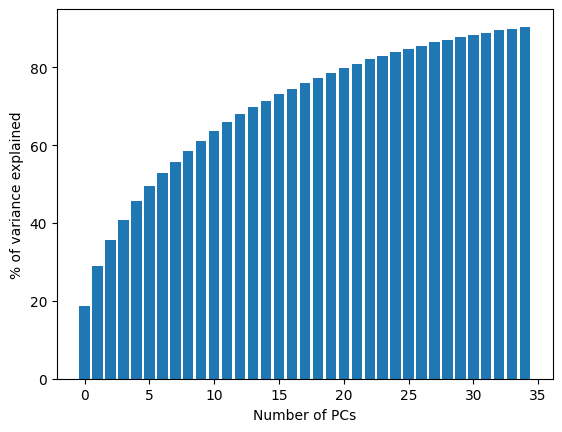

In [284]:
import matplotlib.pyplot as plt

pca = PCA(n_components=k)
x_gex_remainders_pca = pca.fit_transform(x_gex_remainders)
var_exp = pca.explained_variance_ratio_.cumsum()
var_exp = var_exp*100
plt.bar(range(k), var_exp)
plt.xlabel('Number of PCs')
plt.ylabel('% of variance explained')
plt.show()

In [285]:
# from mpl_toolkits.mplot3d import Axes3D

# pca3 = PCA(n_components=3).fit(x_gex)
# X_train_reduced = pca3.transform(x_gex)

# classes = sorted(y.unique())
# colors = plt.cm.Set2([i / len(classes) for i in range(len(classes))])

# plt.close("all")
# fig = plt.figure(figsize=(10, 6))
# ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)

# for cls, color in zip(classes, colors):
#     mask = (y == cls).values
#     ax.scatter(X_train_reduced[mask, 0], X_train_reduced[mask, 1], X_train_reduced[mask, 2],
#                color=color, label=str(cls), s=40)

# ax.set_title("First three PCA directions")
# ax.set_xlabel("1st eigenvector")
# ax.set_ylabel("2nd eigenvector")
# ax.set_zlabel("3rd eigenvector")
# ax.legend(title="pfs_label")
# plt.show()

In [286]:
# plt.close("all")
# fig = plt.figure(figsize=(8, 6))

# for cls, color in zip(classes, colors):
#     mask = (y == cls).values
#     plt.scatter(X_train_reduced[mask, 0], X_train_reduced[mask, 1],
#                 color=color, label=str(cls), s=40)

# plt.title("Plot data using first 2 PCs")
# plt.xlabel("1st eigenvector")
# plt.ylabel("2nd eigenvector")
# plt.legend(title="pfs_label")
# plt.show()

In [287]:
x_gex_remainders_pca = pd.DataFrame(x_gex_remainders_pca, columns=pca.get_feature_names_out())
x_gex_remainders_pca.head()

,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,...,pca25,pca26,pca27,pca28,pca29,pca30,pca31,pca32,pca33,pca34
0,1.217268,0.733795,0.991323,-0.121083,-0.092471,1.213480,0.568981,0.279948,0.465017,-0.439779,...,-0.153425,0.147022,0.174778,-0.603168,0.411073,-0.251269,0.681528,0.651448,0.121294,-0.137151
1,0.398547,0.543873,2.818798,-0.740472,-0.384910,0.706318,0.239619,-0.361650,-0.362009,0.765238,...,-0.189834,0.371168,-0.264497,0.205954,-0.002384,0.377980,1.510398,-0.046432,0.421943,0.785587
2,1.073199,0.205474,-0.633814,1.199952,0.857504,1.213870,-0.440626,0.349364,0.856869,-0.382182,...,-0.428229,-0.436032,-0.065944,-0.164659,-0.260569,-0.567178,0.699247,0.902014,0.210072,-0.919333
3,0.138915,0.485644,-1.724649,-0.535170,-0.262112,-0.643054,0.109628,0.006022,0.490895,0.858817,...,0.446995,-0.222497,0.148428,-0.964333,-0.361286,-0.324517,-1.882186,1.558666,-0.552907,-0.130499
4,0.342039,-1.057823,1.426187,-1.457175,0.001351,-0.592147,-0.653389,0.270898,-0.597846,0.400288,...,-0.356693,-0.406337,-0.239756,1.084337,-0.179947,0.119711,-0.036009,-1.280960,-1.317492,0.997641


## RFE on all features

In [299]:
x_clinical_gex = pd.concat([x_clinical, x_gex_kegg_vcells, x_gex_remainders_pca], axis=1)

clf = RandomForestClassifier(random_state=42)
cv_split = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
rfecv = RFECV(estimator=clf, cv=cv_split, scoring='f1_macro', n_jobs=-1, step=1)

x_clinical_gex_rfe = rfecv.fit_transform(x_clinical_gex, y)
print('Optimal number of features :', rfecv.n_features_)
print(f"Optimal features: {list(rfecv.get_feature_names_out())}")

Optimal number of features : 104
Optimal features: ['m_stage_prep__M_stage', 'remainder__age', 'TIAM1', 'CYLD', 'NRAS', 'GADD45B', 'SKI', 'DIABLO', 'ATR', 'PSMD10', 'HPN', 'MAPK1', 'PIK3CD', 'RAF1', 'CCND1', 'DUSP7', 'GSK3A', 'PAK3', 'CASP9', 'MET', 'EP300', 'YWHAH', 'PDGFRB', 'GNAS', 'BAX', 'PPP3CA', 'SPINT1', 'USP7', 'FGF1', 'CTNNB1', 'CDK4', 'ACTG1', 'MAP2K4', 'HIF1A', 'TNF', 'PRKCE', 'PDGFRA', 'CTXN1', 'FBXW8', 'NACC2', 'FAM89B', 'IER2', 'TAF10', 'GNB5', 'ZFP2', 'CXCR5', 'ARFGEF2', 'POLR3GL', 'FAT1', 'SPAG9', 'LRP11', 'SLC25A37', 'RASSF2', 'SCRG1', 'SLC25A24', 'PTPMT1', 'TUBA8', 'BRI3BP', 'CD300LG', 'ARHGEF10', 'SCARB1', 'PMEPA1', 'BUD31', 'TUBB3', 'C6', 'BMPER', 'COMMD9', 'NOTCH1', 'WDFY2', 'GAP43', 'NHSL2', 'LOC440311', 'COL15A1', 'RPP25', 'ZBTB43', 'MAGEA1', 'ADAM9', 'CORO1C', 'C1QTNF9B', 'TMEM80', 'ZNF691', 'ADAMTS7', 'FXYD3', 'HES6', 'STX2', 'SGCD', 'MXI1', 'PSCA', 'TMEM218', 'FAM120B', 'PLA1A', 'TRAF6', 'LZTS1', 'ALAD', 'PERP', 'CA2', 'SLC31A1', 'EIF3F', 'ERICH1', 'SMPD1', 'Z

In [300]:
selected_features = rfecv.get_feature_names_out()
importances = rfecv.estimator_.feature_importances_

ranked = sorted(zip(selected_features, importances), key=lambda x: x[1], reverse=True)
for feat, imp in ranked:
    print(f"{feat.split('__')[-1]}: {imp:.4f}")


HES6: 0.0302
ZBTB43: 0.0271
CTXN1: 0.0270
SLC31A1: 0.0251
MAGEA1: 0.0234
CXCR5: 0.0203
FAM120B: 0.0181
PMEPA1: 0.0176
IER2: 0.0171
RASSF2: 0.0167
BRI3BP: 0.0160
FAT1: 0.0160
ZNF691: 0.0151
PSCA: 0.0145
ALAD: 0.0144
SCARB1: 0.0138
SYN1: 0.0137
COMMD9: 0.0135
ADAMTS7: 0.0133
EIF3F: 0.0131
TUBA8: 0.0128
WDFY2: 0.0127
LOC440311: 0.0126
FBXW8: 0.0126
CD300LG: 0.0121
C1QTNF9B: 0.0117
BUD31: 0.0113
ARHGEF10: 0.0112
SMPD1: 0.0112
CA2: 0.0108
NOTCH1: 0.0106
RPP25: 0.0106
TSPAN10: 0.0105
SKI: 0.0104
GNB5: 0.0104
SLC25A24: 0.0102
TAF10: 0.0101
SGCD: 0.0101
ERICH1: 0.0101
CORO1C: 0.0100
PTPMT1: 0.0100
SCRG1: 0.0099
TRAF3: 0.0098
ZFP2: 0.0098
TMEM80: 0.0091
LZTS1: 0.0091
ADAM9: 0.0090
LRP11: 0.0089
GAP43: 0.0087
SPAG9: 0.0087
ACTG1: 0.0085
PSMD10: 0.0081
MXI1: 0.0081
PPP3CA: 0.0080
PLA1A: 0.0080
FGF1: 0.0080
SLC25A37: 0.0079
TUBB3: 0.0079
COL15A1: 0.0078
PERP: 0.0076
M_stage: 0.0075
age: 0.0074
CCND1: 0.0074
NACC2: 0.0073
TMEM218: 0.0072
ATR: 0.0072
ARFGEF2: 0.0071
FAM89B: 0.0071
GNAS: 0.0067
POLR3

In [301]:
x_clinical_gex_rfe = pd.DataFrame(x_clinical_gex_rfe, columns=rfecv.get_feature_names_out())
x_clinical_gex_rfe.head()

,m_stage_prep__M_stage,remainder__age,TIAM1,CYLD,NRAS,GADD45B,SKI,DIABLO,ATR,PSMD10,...,PERP,CA2,SLC31A1,EIF3F,ERICH1,SMPD1,ZNF229,TRAF3,TSPAN10,SYN1
0,1.0,26.0,4.740826,5.456537,5.915934,5.661323,5.540349,7.943598,4.342311,7.227893,...,6.450864,5.566860,6.351247,8.136391,6.160624,5.838381,4.181424,5.023265,7.142719,4.493141
1,0.0,58.0,4.617150,5.236413,5.586915,5.635799,5.608741,7.889908,4.468162,7.150913,...,6.397098,5.535641,7.146814,9.068658,6.028205,6.777170,4.069181,4.805716,7.400251,4.486218
2,0.0,45.0,4.881503,6.313049,5.626622,5.767666,5.260630,7.848552,4.603605,7.050374,...,6.509725,5.664685,6.426968,8.281834,6.197951,5.752238,4.103541,5.275061,7.052908,4.486560
3,2.0,48.0,4.562268,5.378751,5.671719,5.877948,5.367287,7.446819,4.209637,7.096730,...,6.448743,6.050421,6.616535,8.383561,5.991895,5.822169,4.001085,4.908581,7.135489,4.485692
4,2.0,33.0,4.667443,5.126189,6.028275,5.652797,5.359803,7.952144,4.554924,7.197295,...,6.272253,5.514046,6.569313,8.846730,6.248220,6.008011,4.241059,4.355761,7.201527,4.473697


In [302]:
clinical_gex = pd.concat([x_clinical_gex_rfe, y], axis=1)
clinical_gex.to_csv('../dataset/created/clinical_gex/clinical_gex_rfe_without_bor.csv')

In [294]:
clinical_gex

,PSMD10,CDKN2A,MAP2K4,pca0,pca1,pca4,pca5,pca7,pca19,pfs_label
0,7.227893,5.530247,5.985015,1.217268,0.733795,-0.092471,1.213480,0.279948,-0.238275,0
1,7.150913,5.516557,5.955284,0.398547,0.543873,-0.384910,0.706318,-0.361650,-0.252161,2
2,7.050374,5.740094,6.040044,1.073199,0.205474,0.857504,1.213870,0.349364,0.135388,2
3,7.096730,5.557027,5.871461,0.138915,0.485644,-0.262112,-0.643054,0.006022,-0.085851,0
4,7.197295,5.780286,5.892498,0.342039,-1.057823,0.001351,-0.592147,0.270898,-0.681023,0
...,...,...,...,...,...,...,...,...,...,...
120,6.273759,6.326623,5.681019,2.221264,3.057351,1.529054,0.142525,0.564607,0.775243,2
121,7.823020,5.831440,6.127754,-0.745268,-4.603020,-0.659646,-0.131614,-0.255805,-0.628549,0
122,7.478320,6.447275,6.075258,-0.483823,-2.159554,0.004896,0.000692,-0.133856,-0.001440,0
123,7.594797,4.870213,5.961411,-1.766037,-2.095877,-1.722885,0.872711,-0.310328,-0.383181,0
